In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('seaborn-whitegrid')
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load the Credit Data

In [3]:
filename = 'default of credit card clients.csv'
credit_data = pd.read_csv(filename)

In [4]:
credit_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Prepare the Dataset

In [5]:
credit_data.drop(['ID'], axis=1, inplace=True)

In [6]:
# Identify number of categories in all categorical variables
categorical_list = ['SEX', 'EDUCATION', 'MARRIAGE']
credit_data[categorical_list].nunique()

SEX          2
EDUCATION    7
MARRIAGE     4
dtype: int64

In [7]:
# One-hot encode
credit_cat_cols = pd.get_dummies(credit_data, columns = categorical_list)

In [8]:
credit_cat_cols.head()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,0,1,0,0,0,0,0,1,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,0,1,0,0,0,0,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,0,1,0,0,0,0,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,0,1,0,0,0,0,0,1,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,0,1,0,0,0,0,0,1,0,0


In [9]:
credit_cat_cols.columns

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month',
       'SEX_1', 'SEX_2', 'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2',
       'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6',
       'MARRIAGE_0', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3'],
      dtype='object')

In [10]:
y = credit_cat_cols['default payment next month'].to_numpy()
X = credit_cat_cols.drop(['default payment next month'], axis=1)

### Test-Train-Validation Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Standard Scaling

In [12]:
standard_scaler = StandardScaler()
scaler_cols = list(set(credit_data.columns) - set(categorical_list))
scaler_cols.remove('default payment next month')
X_train_scaled = standard_scaler.fit_transform(X_train[scaler_cols])
X_train[scaler_cols] = X_train_scaled

In [13]:
X_test_scaled = standard_scaler.transform(X_test[scaler_cols])
X_test[scaler_cols] = X_test_scaled

In [14]:
input_cols = X_train.shape[1]
input_cols

33

In [15]:
no_epochs = 100
batch_size = 100

In [16]:
def createDataLoader(X, y, shuffle):
    tx = torch.Tensor(X).to(device)
    ty = torch.Tensor(y).to(device)
    dataset = TensorDataset(tx, ty)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, 
                                         shuffle=shuffle, drop_last=True)
    return loader

### Build Model

In [17]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs, level = 0.5):
    train_errors = []
    test_errors = []
    train_accuracies = []
    test_accuracies = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0
        correct_train = 0

        # Training
        for batch_X, batch_y in train_loader:
            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs.squeeze(), batch_y.float())

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

            # Calculate training accuracy
            predicted = outputs.squeeze() > level
            correct_train += (predicted == batch_y).sum().item()

        train_loss /= len(train_loader.dataset)
        train_accuracy = 100 * correct_train / len(train_loader.dataset)
        train_errors.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Evaluation on test set
        model.eval()
        test_loss = 0.0
        correct_test = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                loss = loss_fn(outputs.squeeze(), batch_y.float())
                test_loss += loss.item() * batch_X.size(0)

                # Calculate test accuracy
                predicted = outputs.squeeze() > level
                correct_test += (predicted == batch_y).sum().item()

        test_loss /= len(test_loader.dataset)
        test_accuracy = 100 * correct_test / len(test_loader.dataset)
        test_errors.append(test_loss)
        test_accuracies.append(test_accuracy)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracy:.2f}%")

    history = {}
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    history['train_acc'] = train_accuracies
    history['test_acc'] = test_accuracies
        
    return history

In [18]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_activation='sigmoid'):
        super(BinaryClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, 1)

        if output_activation == 'sigmoid':
            self.output_activation = nn.Sigmoid()
        elif output_activation == 'tanh':
            self.output_activation = nn.Tanh()
        else:
            raise ValueError("Invalid output activation. Choose 'sigmoid' or 'tanh'.")

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        x = self.output_activation(x)
        return x


### K-Fold Cross-Validation

In [19]:
from sklearn.model_selection import KFold

In [20]:
no_splits = 5
kf = KFold(n_splits=no_splits)

In [21]:
X_train = X_train.to_numpy()

In [22]:
all_histories = []
current_split = 0
for train_index, val_index in kf.split(X_train, y_train):
    iX_train, iX_val = X_train[train_index], X_train[val_index]
    iy_train, iy_val = y_train[train_index], y_train[val_index]
    train_loader = createDataLoader(iX_train, iy_train, True)
    val_loader = createDataLoader(iX_val, iy_val, False)
    
    print("Processing fold: {0}".format(current_split))
    current_split = current_split + 1
    
    model = BinaryClassifier(input_cols, 50).to(device)
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history_dict = train_model(model, train_loader, val_loader,
                       loss_fn, optimizer, no_epochs)
    val_history = history_dict['test_acc']
    all_histories.append(val_history)

Processing fold: 0


  0%|          | 0/100 [00:00<?, ?it/s]

Processing fold: 1


  0%|          | 0/100 [00:00<?, ?it/s]

Processing fold: 2


  0%|          | 0/100 [00:00<?, ?it/s]

Processing fold: 3


  0%|          | 0/100 [00:00<?, ?it/s]

Processing fold: 4


  0%|          | 0/100 [00:00<?, ?it/s]

In [24]:
average_history = [np.mean([x[i] for x in all_histories]) for i in range(no_epochs)]

### Validation Accuracy

In [25]:
epochs = range(1, no_epochs + 1)

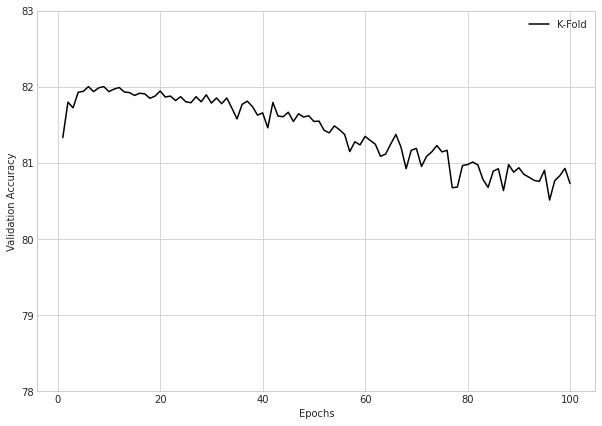

In [26]:
plt.figure(figsize=(10,7)) 
    
plt.plot(epochs, average_history, color='k', linestyle='-', label = 'K-Fold')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.ylim(78, 83)
plt.legend()
plt.savefig('TestTCKFoldValidAcc.png', dpi=300, bbox_inches='tight')

### Retrain using whole training set

In [28]:
train_loader = createDataLoader(X_train, y_train, True)
val_loader = createDataLoader(X_test.to_numpy(), y_test, False)
    
model = BinaryClassifier(input_cols, 50).to(device)
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = train_model(model, train_loader, val_loader,
                       loss_fn, optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

### Evaluation Metrics

In [33]:
tx = torch.Tensor(X_test.to_numpy()).to(device)
y_predict = model(tx)
y_pred = np.array([1 if i > 0.5 else 0 for i in y_predict])

In [34]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy = {}".format(accuracy))

Accuracy = 0.8098333333333333


In [35]:
# Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy = {}".format(balanced_accuracy))

Balanced Accuracy = 0.6345794325702943


In [36]:
# Precision
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision = {}".format(precision))

Precision = 0.6272189349112426


In [37]:
# Recall
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("Recall = {}".format(recall))

Recall = 0.32292460015232294


In [38]:
# F1-Score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1-Score = {}".format(f1))

F1-Score = 0.42634489693313227


In [40]:
# AUC
from sklearn.metrics import roc_auc_score
# Note use of raw probabilities
auc = roc_auc_score(y_test, y_pred)
print("AUC = {}".format(auc))

AUC = 0.6345794325702941


### ROC curve

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred)

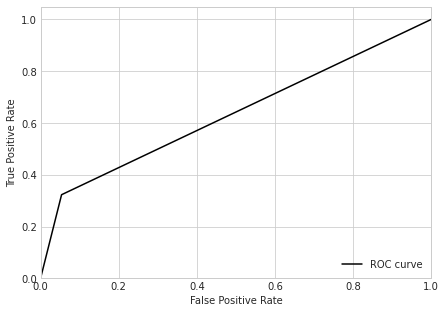

In [43]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='k', label='ROC curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('TestTCROCCurve.png', dpi=300, bbox_inches='tight')